In [2]:
import numpy as np
import MDAnalysis as mda
from scipy.spatial import distance
import os
from tqdm import tqdm

In [7]:
# System definitions
systems = {
    "matchHBWIDOMH3": {"dir": "WIDOMH3", "entry": (786, 839), "exit": (295, 348)},
    "matchHBWIDOMcenpa": {"dir": "WIDOMcenpa", "entry": (790, 842), "exit": (295, 347)},
}

cutoff = 8.0
replica_size = 20001
n_replicas = 4
skip = 10


def compute_contacts(u, residue_range):

    dna = u.select_atoms("resid 1:294")
    results = {}

    for resid in tqdm(
        range(residue_range[0], residue_range[1] + 1),
        desc="Residues"
    ):

        tail = u.select_atoms(f"resid {resid} and name CA")

        if len(tail) == 0:
            continue

        replica_means = []

        for rep in range(n_replicas):

            start = rep * replica_size
            stop = (rep + 1) * replica_size

            contact_sum = 0
            n_frames = 0

            for ts in u.trajectory[start:stop:skip]:

                d = distance.cdist(dna.positions, tail.positions)
                contact_sum += np.sum(d < cutoff)
                n_frames += 1

            replica_means.append(contact_sum / n_frames)

        replica_means = np.array(replica_means)

        mean = np.mean(replica_means)
        sem = np.std(replica_means, ddof=1) / np.sqrt(n_replicas)

        results[resid] = (mean, sem)

    return results


# Loop over systems
for system, info in systems.items():

    print(f"Processing {system}...")

    system_dir = info["dir"]

    # Directory is WIDOMH3/WIDOMcenpa,
    # but filename contains matchHBWIDOMH3/matchHBWIDOMcenpa
    pdb_file = os.path.join(
        system_dir,
        f"min_{system}_renumresidues.pdb"
    )

    xtc_file = os.path.join(
        system_dir,
        "combined_aligned.dcd"
    )

    if not os.path.exists(pdb_file):
        print(f"WARNING: Missing {pdb_file}, skipping.")
        continue

    if not os.path.exists(xtc_file):
        print(f"WARNING: Missing {xtc_file}, skipping.")
        continue

    u = mda.Universe(pdb_file, xtc_file)

    entry_results = compute_contacts(u, info["entry"])
    exit_results = compute_contacts(u, info["exit"])

    entry_file = os.path.join(
        system_dir,
        f"{system}_entry_tail_contacts.dat"
    )

    exit_file = os.path.join(
        system_dir,
        f"{system}_exit_tail_contacts.dat"
    )

    with open(entry_file, "w") as f:
        f.write("#Resid  MeanContacts  SEM\n")
        for resid, (mean, sem) in entry_results.items():
            f.write(f"{resid} {mean:.6f} {sem:.6f}\n")

    with open(exit_file, "w") as f:
        f.write("#Resid  MeanContacts  SEM\n")
        for resid, (mean, sem) in exit_results.items():
            f.write(f"{resid} {mean:.6f} {sem:.6f}\n")

    print(f"{system} done. Files written inside {system_dir}/\n")

/Users/jlee295/miniconda3/envs/pyemma/lib/python3.11/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "
/Users/jlee295/miniconda3/envs/pyemma/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"


Processing matchHBWIDOMH3...


Residues: 100%|██████████| 54/54 [00:49<00:00,  1.09it/s]


matchHBWIDOMH3 done. Files written inside WIDOMH3/

Processing matchHBWIDOMcenpa...


Residues: 100%|██████████| 53/53 [00:49<00:00,  1.08it/s]

matchHBWIDOMcenpa done. Files written inside WIDOMcenpa/



In [8]:
import numpy as np
import matplotlib.pyplot as plt
import os

width = 0.28  # bar width

# -----------------------------
# Residue sequences (trimmed)
# -----------------------------
listH3 = ['A1','R2','T3','K4','Q5','T6','A7','R8','K9','S10',
          'T11','G12','G13','K14','A15','P16','R17','K18','Q19','L20',
          'A21','T22','K23','A24','A25','R26','K27','S28','A29','P30',
          'A31','T32','G33','G34','V35','K36','K37','P38','H39','R40',
          'Y41','R42','P43','G44','T45','V46','A47','L48','R49','E50',
          'I51','R52','R53','Y54']

listcenpa = ['G1','P2','R3','R4','R5','S6','R7','K8','P9','E10',
             'A11','P12','R13','R14','R15','S16','P17','S18','P19','T20',
             'P21','T22','P23','G24','P25','S26','R27','R28','G29','P30',
             'S31','L32','G33','A34','S35','S36','H37','Q38','H39','S40',
             'R41','R42','R43','Q44','G45','W46','L47','K48','E49','I50',
             'R51','K52','L53']

In [15]:
import os
import numpy as np
import pandas as pd

# -----------------------------
# Systems
# -----------------------------
systems = {"WIDOMH3": "matchHBWIDOMH3", "WIDOMcenpa": "matchHBWIDOMcenpa"}

# -----------------------------
# Region definitions
# format: (range1, range2)
# -----------------------------
regions = {
    "WIDOMH3": {
        "tails": [(295,331), (786,822)],
        "latch": [(332,338), (823,829)],
        "alphaN": [(339,348), (830,839)]
    },
    "WIDOMcenpa": {
        "tails": [(295,330), (790,825)],
        "latch": [(331,337), (826,832)],
        "alphaN": [(338,347), (833,842)]
    }
}

# -----------------------------
# Helper: sum region
# -----------------------------
def compute_region(data, ranges):
    mask = np.zeros(len(data), dtype=bool)

    for start, end in ranges:
        mask |= (data[:,0] >= start) & (data[:,0] <= end)

    selected = data[mask]

    total_contacts = np.sum(selected[:,1])
    total_sem = np.sqrt(np.sum(selected[:,2]**2))

    return total_contacts, total_sem

# -----------------------------
# Main loop
# -----------------------------
results = []

for system_dir, file_prefix in systems.items():

    for tail_type in ["entry", "exit"]:

        filepath = os.path.join(
            system_dir,
            f"{file_prefix}_{tail_type}_tail_contacts.dat"
        )

        if not os.path.exists(filepath):
            print(f"Missing: {filepath}")
            continue

        data = np.loadtxt(filepath, comments="#")

        for region_name, ranges in regions[system_dir].items():

            total, sem = compute_region(data, ranges)

            results.append([
                system_dir,
                tail_type,
                region_name,
                total,
                sem
            ])

# -----------------------------
# Save output
# -----------------------------
df = pd.DataFrame(results, columns=[
    "System", "Tail", "Region", "TotalContacts", "SEM"
])

df.to_csv("cumulative_tail_contacts_WIDOM601.dat", index=False, sep="\t")

print("Done! Output: cumulative_tail_contacts_WIDOM601.dat")

Done! Output: cumulative_tail_contacts_WIDOM601.dat


/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_75795/2553683792.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])
/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_75795/2553683792.py:23: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return float(row["TotalContacts"]), float(row["SEM"])


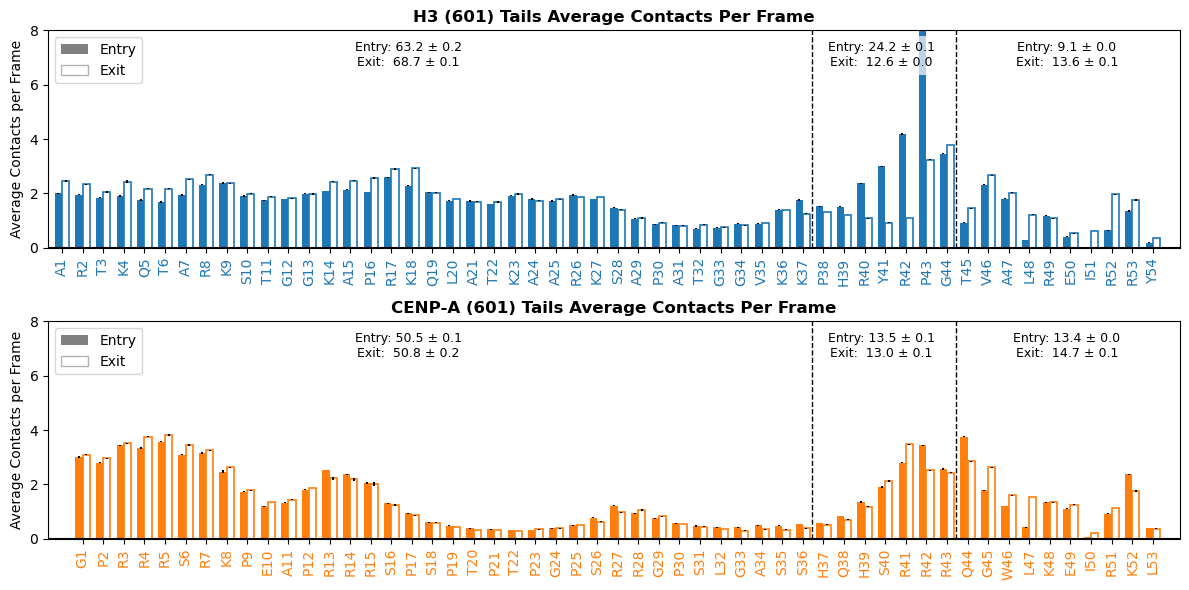

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import pandas as pd

tab20 = plt.get_cmap("tab20")
width = 0.35  # bar width

# -----------------------------
# Load cumulative data
# -----------------------------
cum_df = pd.read_csv("cumulative_tail_contacts_WIDOM601.dat", sep="\t")

def get_cumulative(system, tail_type, region):
    row = cum_df[
        (cum_df["System"] == system) &
        (cum_df["Tail"] == tail_type) &
        (cum_df["Region"] == region)
    ]
    if len(row) == 0:
        return None, None
    return float(row["TotalContacts"]), float(row["SEM"])

# -----------------------------
# Load data function
# -----------------------------
def load_tail_data(system_dir, file_prefix, tail_type):
    path = os.path.join(system_dir, f"{file_prefix}_{tail_type}_tail_contacts.dat")
    data = np.loadtxt(path, comments="#")
    return data[:,1], data[:,2]  # avg, SEM

# -----------------------------
# Plotting function
# -----------------------------
def plot_system(ax, avg_entry, ste_entry, avg_exit, ste_exit, labels, default_color,
                entry_alpha=1.0, exit_alpha=0.6, highlight=None, subtitle=None,
                remove_first_tick=False, system_name=None):

    highlight = highlight or {}
    num_slots = len(labels)
    x = np.arange(1, num_slots+1)

    # Plot bars
    for i in range(num_slots):
        color = highlight.get(i, default_color)
        if avg_entry[i] is not None:
            ax.bar(x[i], avg_entry[i], width=width,
                   yerr=ste_entry[i], color=color, alpha=entry_alpha)
        if avg_exit[i] is not None:
            ax.bar(x[i]+width, avg_exit[i], width=width,
                   yerr=ste_exit[i], facecolor='white', edgecolor=color, linewidth=1.2)

    # Vertical lines and baseline
    ax.axvline(37.6, color='k', linestyle='--', lw=1)
    ax.axvline(44.6, color='k', linestyle='--', lw=1)
    ax.axhline(0, color='black')

    # Tick handling
    tick_indices = [i for i in range(num_slots)
                    if avg_entry[i] is not None or avg_exit[i] is not None]

    if remove_first_tick:
        tick_indices = tick_indices[1:]

    x_ticks = x[tick_indices] + width / 2
    x_labels = [labels[i] for i in tick_indices]

    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=90)

    for lbl, i in zip(ax.get_xticklabels(), tick_indices):
        lbl.set_color(highlight.get(i, default_color))

    ax.set_ylim(0, 8)
    ax.set_ylabel("Average Contacts per Frame")

    if subtitle:
        ax.set_title(subtitle, fontsize=12, fontweight='bold')

    # -----------------------------
    # ADD: Region annotations
    # -----------------------------
    if system_name is not None:

        # Region centers
        tail_center = 18
        latch_center = 41
        alpha_center = 50

        y_top = ax.get_ylim()[1] * 0.95

        regions = ["tails", "latch", "alphaN"]
        centers = [tail_center, latch_center, alpha_center]

        for region, xpos in zip(regions, centers):

            entry_val, entry_sem = get_cumulative(system_name, "entry", region)
            exit_val, exit_sem = get_cumulative(system_name, "exit", region)

            if entry_val is None:
                continue

            text = (
                f"Entry: {entry_val:.1f} ± {entry_sem:.1f}\n"
                f"Exit:  {exit_val:.1f} ± {exit_sem:.1f}"
            )

            ax.text(
                xpos,
                y_top,
                text,
                ha='center',
                va='top',
                fontsize=9,
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none')
            )

    # Legend
    legend_handles = [
        Patch(facecolor='gray', alpha=entry_alpha, label="Entry"),
        Patch(facecolor='white', edgecolor='gray', alpha=exit_alpha, label="Exit")
    ]
    ax.legend(handles=legend_handles)

    ax.set_xlim(0.5, len(listH3) + 1.5)

# -----------------------------
# Load data
# -----------------------------
avg_entry_H3, ste_entry_H3 = load_tail_data("WIDOMH3", "matchHBWIDOMH3", "entry")
avg_exit_H3, ste_exit_H3 = load_tail_data("WIDOMH3", "matchHBWIDOMH3", "exit")

avg_entry_cenpa, ste_entry_cenpa = load_tail_data("WIDOMcenpa", "matchHBWIDOMcenpa", "entry")
avg_exit_cenpa, ste_exit_cenpa = load_tail_data("WIDOMcenpa", "matchHBWIDOMcenpa", "exit")

# -----------------------------
# Prepare data
# -----------------------------
num_slots = len(listH3)

# CENP-A padding
avg_entry_cenpa_plot = [0] + list(avg_entry_cenpa)
ste_entry_cenpa_plot = [0] + list(ste_entry_cenpa)
avg_exit_cenpa_plot = [0] + list(avg_exit_cenpa)
ste_exit_cenpa_plot = [0] + list(ste_exit_cenpa)
labels_cenpa_plot = [""] + list(listcenpa)

highlight_H3 = {}
highlight_cenpa = {}

# -----------------------------
# Generate figure
# -----------------------------
fig, axes = plt.subplots(2, 1, figsize=(12,6), sharex=False)

# H3
plot_system(
    axes[0],
    avg_entry_H3, ste_entry_H3,
    avg_exit_H3, ste_exit_H3,
    listH3,
    tab20(0),
    subtitle="H3 (601) Tails Average Contacts Per Frame",
    system_name="WIDOMH3"
)

# CENP-A
plot_system(
    axes[1],
    avg_entry_cenpa_plot, ste_entry_cenpa_plot,
    avg_exit_cenpa_plot, ste_exit_cenpa_plot,
    labels_cenpa_plot,
    tab20(2),
    subtitle="CENP-A (601) Tails Average Contacts Per Frame",
    remove_first_tick=True,
    system_name="WIDOMcenpa"
)

plt.tight_layout()
plt.savefig('wildtype_WIDOM601_CG_BYRES_CONTACTS.pdf')
plt.show()